In [72]:
import pandas as pd
import matplotlib.pyplot as plt

deals_df = pd.read_csv("clear_deals.csv")
projects_df = pd.read_csv("clear_projects.csv")

deals_df = deals_df[deals_df["тип_лота"] == "квартира"]
projects_df = projects_df[projects_df["тип_объекта_недвижимости"] == "квартира"]

,id_корпуса,стадия_строительства,девелопер,building_floors_count,total_flats_in_building,плановая_дата_рвэ,floor,deals_count,sales_share,sales_share_group,flats_per_floor,avg_flat_area,avg_price_per_sqm,avg_floor_area_A,total_project_area,avg_floor_area_B,developer_total_buildings
0,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,Абсолют Недвижимость,17,549,2025-08-21,522.314286,312,0.568306,Ниже_медианы,32.0,53.277960,211137.297571,28983.210200,348500.60,20500.035294,24
1,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,А101,17,185,2025-06-17,100.187059,154,0.832432,Выше_или_равно_медианы,11.0,46.031892,230538.094875,8607.963784,22657.90,1332.817647,176
2,059550c08c9b9a9f1a38d43293930e67,Введен в эксплуатацию,Самолет,10,101,2025-04-11,120.191316,53,0.524752,Ниже_медианы,10.0,45.220495,194094.698758,4522.049505,15439.65,1543.965000,93
3,08810b5305ca2c2da6e9e1aa5db0174b,Введен в эксплуатацию,Самолет,13,494,2024-11-12,473.454038,365,0.738866,Выше_или_равно_медианы,38.0,49.837267,206479.621843,24619.610000,285192.69,21937.899231,93
4,0cf1f9c7f125467ce3cc55ebdebebdff,Введен в эксплуатацию,А101,7,77,2025-09-24,133.160714,67,0.870130,Выше_или_равно_медианы,11.0,48.422078,215736.937259,3728.500000,10866.20,1552.314286,176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,f5fd178be7b9fcfafa73a52df8c4696f,Введен в эксплуатацию,Абсолют Недвижимость,12,298,2024-08-28,585.953125,99,0.332215,Ниже_медианы,25.0,62.921141,253922.372532,18876.342282,217211.40,18100.950000,24
113,f88eb31294efa9ae4e42d6eea84414cc,Введен в эксплуатацию,А101,15,128,2025-07-30,82.657333,118,0.921875,Выше_или_равно_медианы,9.0,48.432031,265378.060341,6538.324219,13311.00,887.400000,176
114,fc7dbe2d2ed10547d097316bf6a10e3b,Введен в эксплуатацию,А101,17,185,2025-05-30,123.395652,158,0.854054,Выше_или_равно_медианы,11.0,46.023243,225271.493152,8606.346486,24774.10,1457.300000,176
115,fde1f8ad4322f757d44bdf4c634df283,Введен в эксплуатацию,А101,17,185,2025-05-30,121.002857,153,0.827027,Выше_или_равно_медианы,11.0,45.784865,250383.975641,8561.769730,26564.10,1562.594118,176


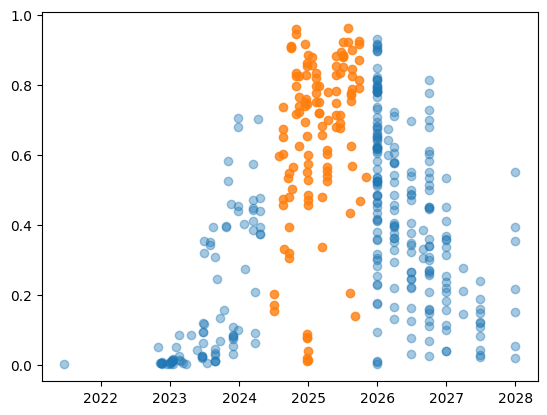

In [139]:
projects_buildings_df = (
    projects_df[projects_df["тип_объекта_недвижимости"] == "квартира"]
    .groupby("id_корпуса")
    .agg(
        # стадия строительства корпус
        стадия_строительства=("стадия_строительства", "first"),

        девелопер=("девелопер", "first"),

        # этажность дома
        building_floors_count=("этаж", "nunique"),

        # общее количество квартир в корпусе
        total_flats_in_building=("количество_лотов", "sum"),

        плановая_дата_рвэ=("плановая_дата_рвэ", "first"),

        floor=("общая_проектная_площадь", "mean")
    )
    .reset_index()
)

deals_count_by_building_df = (
    deals_df[deals_df["тип_лота"] == "квартира"]
    .groupby("id_корпуса")
    .size()
    .reset_index(name="deals_count")
)

deals_count_by_building_df.head()

projects_buildings_df = projects_buildings_df.merge(
    deals_count_by_building_df,
    on="id_корпуса",
    how="left"
)

# если по корпусу не было сделок
projects_buildings_df["deals_count"] = (
    projects_buildings_df["deals_count"]
    .fillna(0)
    .astype(int)
)

projects_buildings_df["плановая_дата_рвэ"] = pd.to_datetime(
    projects_buildings_df["плановая_дата_рвэ"],
    errors="coerce"
)

start_date = pd.Timestamp("2024-07-01")  # середина 2024

buildings_group_df = projects_buildings_df.copy()

buildings_group_df["sales_share"] = (
    buildings_group_df["deals_count"]
    / buildings_group_df["total_flats_in_building"]
)

# границы дат
end_date = pd.Timestamp("2025-11-30")

mask_2024_2026 = (
    (buildings_group_df["плановая_дата_рвэ"] >= start_date) &
    (buildings_group_df["плановая_дата_рвэ"] < end_date)
)

# остальные корпуса
plt.scatter(
    buildings_group_df.loc[~mask_2024_2026, "плановая_дата_рвэ"],
    buildings_group_df.loc[~mask_2024_2026, "sales_share"],
    alpha=0.4,
    label="Остальные корпуса"
)

# выделенные корпуса
plt.scatter(
    buildings_group_df.loc[mask_2024_2026, "плановая_дата_рвэ"],
    buildings_group_df.loc[mask_2024_2026, "sales_share"],
    alpha=0.8,
    label="РВЭ: II пол. 2024 – 2025"
)

buildings_group_df = buildings_group_df[
    (projects_buildings_df["стадия_строительства"] == "Введен в эксплуатацию") &
    (projects_buildings_df["плановая_дата_рвэ"] > start_date)
]

median_sales_share = buildings_group_df["sales_share"].median()

buildings_group_df["sales_share_group"] = (
    buildings_group_df["sales_share"] >= median_sales_share
).map({
    True: "Выше_или_равно_медианы",
    False: "Ниже_медианы"
})

buildings_group_df["flats_per_floor"] = (
    buildings_group_df["total_flats_in_building"]
    / buildings_group_df["building_floors_count"]
).round()
buildings_group_df["flats_per_floor"]

project_area_agg = (
    projects_df
    .groupby("id_корпуса")
    .agg(
        total_project_area=("общая_проектная_площадь", "sum"),
        total_lots=("количество_лотов", "sum")
    )
    .reset_index()
)

project_area_agg["avg_flat_area"] = (
    project_area_agg["total_project_area"]
    / project_area_agg["total_lots"]
)

project_area_agg

price_agg = (
    deals_df
    .groupby("id_корпуса")
    .agg(
        total_deal_area=("площадь_объекта", "sum"),
        total_deal_budget=("реальная_сумма_бюджета", "sum"),
        deals_count=("id_корпуса", "count")
    )
    .reset_index()
)

price_agg["avg_price_per_sqm"] = (
    price_agg["total_deal_budget"]
    / price_agg["total_deal_area"]
)

buildings_group_df = (
    buildings_group_df
    .merge(
        project_area_agg[["id_корпуса", "avg_flat_area"]],
        on="id_корпуса",
        how="left"
    )
    .merge(
        price_agg[["id_корпуса", "avg_price_per_sqm"]],
        on="id_корпуса",
        how="left"
    )
)

# ПЛОЩАДЬ НА ЭТАЖ

buildings_group_df["avg_floor_area_A"] = (
    buildings_group_df["avg_flat_area"]
    * buildings_group_df["flats_per_floor"] * buildings_group_df["building_floors_count"]
)

projects_df["project_area_row_sum"] = (
    projects_df["общая_проектная_площадь"]
    * projects_df["количество_лотов"]
)

total_project_area_by_building = (
    projects_df
    .groupby("id_корпуса", as_index=False)
    .agg(
        total_project_area=("project_area_row_sum", "sum")
    )
)

buildings_group_df = buildings_group_df.merge(
    total_project_area_by_building,
    on="id_корпуса",
    how="left"
)

buildings_group_df["avg_floor_area_B"] = (
    buildings_group_df["total_project_area"]
    / buildings_group_df["building_floors_count"]
)

# девелопер

developer_buildings_count = (
    projects_df
    .groupby("девелопер", as_index=False)
    .agg(
        developer_total_buildings=("id_корпуса", "nunique")
    )
)

buildings_group_df = buildings_group_df.merge(
    developer_buildings_count,
    on="девелопер",
    how="left"
)

buildings_group_df

Коэффициент наклона (β1): 0.0017
Свободный член (β0): 0.4432
R²: 0.242


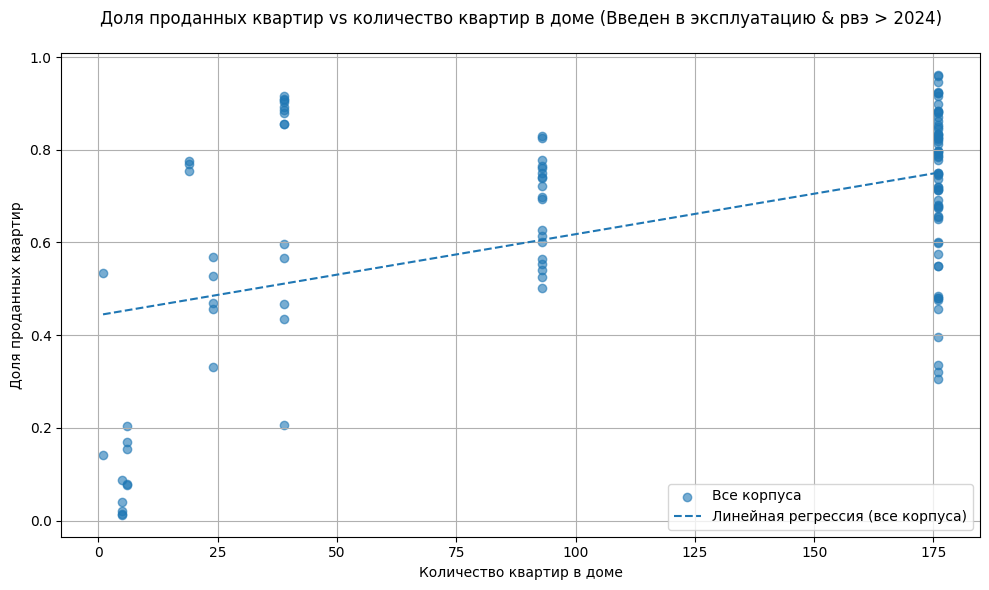

In [112]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = buildings_group_df["developer_total_buildings"].values.reshape(-1, 1)
y = buildings_group_df["sales_share"].values

model_all = LinearRegression()
model_all.fit(X, y)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model_all.predict(x_line)

print(f"Коэффициент наклона (β1): {model_all.coef_[0]:.4f}")
print(f"Свободный член (β0): {model_all.intercept_:.4f}")
print(f"R²: {model_all.score(X, y):.3f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    buildings_group_df["developer_total_buildings"],
    buildings_group_df["sales_share"],
    alpha=0.6,
    label="Все корпуса"
)

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    label="Линейная регрессия (все корпуса)"
)

plt.xlabel("Количество квартир в доме")
plt.ylabel("Доля проданных квартир")
plt.title("Доля проданных квартир vs количество квартир в доме (Введен в эксплуатацию & рвэ > 2024)\n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [113]:
from scipy import stats

categories = [
    "total_flats_in_building",
    "building_floors_count",
    "avg_flat_area",
    "flats_per_floor",
    "avg_price_per_sqm",
    "avg_floor_area_B",
    "developer_total_buildings"
]

for cat in categories:
    print(f'"{cat}"')
    low_group = buildings_group_df.loc[
        buildings_group_df["sales_share_group"] == "Ниже_медианы",
        cat
    ]

    high_group = buildings_group_df.loc[
        buildings_group_df["sales_share_group"] == "Выше_или_равно_медианы",
        cat
    ]

    t_stat, p_value = stats.ttest_ind(
        low_group,
        high_group,
        equal_var=False
    )

    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.4f}")

    print(f"Mean (Ниже медианы): {low_group.mean():.1f}")
    print(f"Mean (Выше медианы): {high_group.mean():.1f}")
    print("____________")

"total_flats_in_building"
t-statistic: 2.120
p-value: 0.0371
Mean (Ниже медианы): 325.4
Mean (Выше медианы): 228.0
____________
"building_floors_count"
t-statistic: 0.008
p-value: 0.9939
Mean (Ниже медианы): 13.8
Mean (Выше медианы): 13.8
____________
"avg_flat_area"
t-statistic: 1.226
p-value: 0.2229
Mean (Ниже медианы): 48.6
Mean (Выше медианы): 46.9
____________
"flats_per_floor"
t-statistic: 2.240
p-value: 0.0272
Mean (Ниже медианы): 23.5
Mean (Выше медианы): 17.4
____________
"avg_price_per_sqm"
t-statistic: -1.802
p-value: 0.0753
Mean (Ниже медианы): 217601.8
Mean (Выше медианы): 232770.8
____________
"avg_floor_area_B"
t-statistic: 1.849
p-value: 0.0679
Mean (Ниже медианы): 14960.6
Mean (Выше медианы): 8072.7
____________
"developer_total_buildings"
t-statistic: -2.846
p-value: 0.0053
Mean (Ниже медианы): 100.0
Mean (Выше медианы): 135.2
____________


                            OLS Regression Results                            
Dep. Variable:            sales_share   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     36.67
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           1.81e-08
Time:                        17:50:22   Log-Likelihood:                 16.292
No. Observations:                 117   AIC:                            -28.58
Df Residuals:                     115   BIC:                            -23.06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

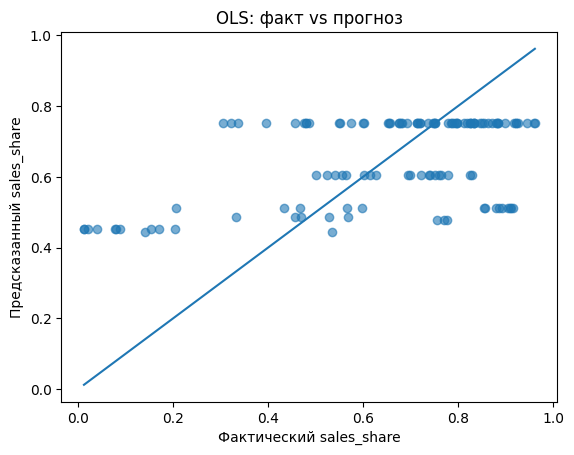

"developer_total_buildings"
t-statistic: -2.846
p-value: 0.0053
Mean (Ниже медианы): 100.0
Mean (Выше медианы): 135.2
____________


In [143]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

features = [
    "developer_total_buildings"
]

df_reg = buildings_group_df[features + ["sales_share"]].copy()

# приведение к numeric
for c in features + ["sales_share"]:
    df_reg[c] = pd.to_numeric(df_reg[c], errors="coerce")

# чистка
df_reg = (
    df_reg
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = sm.add_constant(df_reg[features])
y = df_reg["sales_share"]

model = sm.OLS(y, X).fit()

print(model.summary())
print(f"R² = {model.rsquared:.3f}")
print(f"Adj. R² = {model.rsquared_adj:.3f}")

y_pred = model.predict(X)

plt.figure()
plt.scatter(y, y_pred, alpha=0.6)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Фактический sales_share")
plt.ylabel("Предсказанный sales_share")
plt.title("OLS: факт vs прогноз")
plt.show()

for cat in features:
    print(f'"{cat}"')
    low_group = buildings_group_df.loc[
        buildings_group_df["sales_share_group"] == "Ниже_медианы",
        cat
    ]

    high_group = buildings_group_df.loc[
        buildings_group_df["sales_share_group"] == "Выше_или_равно_медианы",
        cat
    ]

    t_stat, p_value = stats.ttest_ind(
        low_group,
        high_group,
        equal_var=False
    )

    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.4f}")

    print(f"Mean (Ниже медианы): {low_group.mean():.1f}")
    print(f"Mean (Выше медианы): {high_group.mean():.1f}")
    print("____________")